In [1]:
import xarray as xr
from pathlib import Path
from xhistogram.xarray import histogram as xhist
import numpy as np
import matplotlib.pyplot as plt

In [2]:
stores = sorted(Path("../data/tracks").glob("Parcels_run_*_*.zarr"))
stores

[PosixPath('../data/tracks/Parcels_run_1234_2022-06-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-07-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-08-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-09-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-10-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-11-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2022-12-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-01-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-02-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-03-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-04-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-05-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-06-01T00:00:00.zarr'),
 PosixPath('../data/tracks/Parcels_run_1234_2023-07-01T00:00:00.

In [3]:
ds_list = [xr.open_zarr(s).assign(stores=s.name) for s in stores]
ds = xr.concat(ds_list,dim='trajectory')

ds

<xarray.Dataset> Size: 71GB
Dimensions:     (trajectory: 3800000, obs: 925)
Coordinates:
  * obs         (obs) int32 4kB 0 1 2 3 4 5 6 7 ... 918 919 920 921 922 923 924
  * trajectory  (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 28GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 14GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    stores      (trajectory) <U41 623MB 'Parcels_run_1234_2022-06-01T00:00:00...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [4]:
valid_data = ds.lat.notnull().any('trajectory').compute()
ds=ds.where(valid_data,drop=True)
ds=ds.assign(stores=ds.stores.isel(obs=0))
ds

<xarray.Dataset> Size: 56GB
Dimensions:     (trajectory: 3800000, obs: 741)
Coordinates:
  * obs         (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * trajectory  (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat         (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon         (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time        (trajectory, obs) datetime64[ns] 23GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z           (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    stores      (trajectory) object 30MB 'Parcels_run_1234_2022-06-01T00:00:0...
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [5]:
start_time = ds['time'].isel(obs=0).compute()
start_season = start_time.dt.season

ds['start_season'] = start_season
ds

<xarray.Dataset> Size: 56GB
Dimensions:       (trajectory: 3800000, obs: 741)
Coordinates:
  * obs           (obs) int32 3kB 0 1 2 3 4 5 6 ... 734 735 736 737 738 739 740
  * trajectory    (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat           (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon           (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time          (trajectory, obs) datetime64[ns] 23GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z             (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    stores        (trajectory) object 30MB 'Parcels_run_1234_2022-06-01T00:00...
    start_season  (trajectory) <U3 46MB 'JJA' 'JJA' 'JJA' ... 'JJA' 'JJA' 'JJA'
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [6]:
lat_min=ds.lat.min().compute().data[()]
lon_min=ds.lon.min().compute().data[()]

lat_max=ds.lat.max().compute().data[()]
lon_max=ds.lon.max().compute().data[()]

In [7]:
# ds.z.min().compute().data[()]
z_max = ds.z.max().compute().data[()]

In [8]:
# import numpy as np

lat_bins = np.linspace(lat_min,lat_max,30)
lon_bins = np.linspace(lon_min,lon_max,30)
# z_bins = np.linspace(0, z_max, 45)  

def calc_hist(ds):
    return xhist(
        ds.lon,
        ds.lat,
        # ds.z,
        bins=[lon_bins, lat_bins,],
        dim=["trajectory", ],
        bin_dim_suffix=""
    )

### Seasonal Variability

In [9]:
hist = ds.groupby('start_season').apply(calc_hist)
hist

<xarray.DataArray 'histogram_lon_lat' (start_season: 4, obs: 741, lon: 29,
                                       lat: 29)> Size: 20MB
dask.array<concatenate, shape=(4, 741, 29, 29), dtype=int64, chunksize=(1, 185, 29, 29), chunktype=numpy.ndarray>
Coordinates:
  * obs           (obs) int32 3kB 0 1 2 3 4 5 6 ... 734 735 736 737 738 739 740
  * lon           (lon) float32 116B -90.52 -87.34 -84.17 ... -4.764 -1.588
  * lat           (lat) float32 116B -5.54 -4.011 -2.482 ... 34.22 35.75 37.28
  * start_season  (start_season) object 32B 'DJF' 'JJA' 'MAM' 'SON'

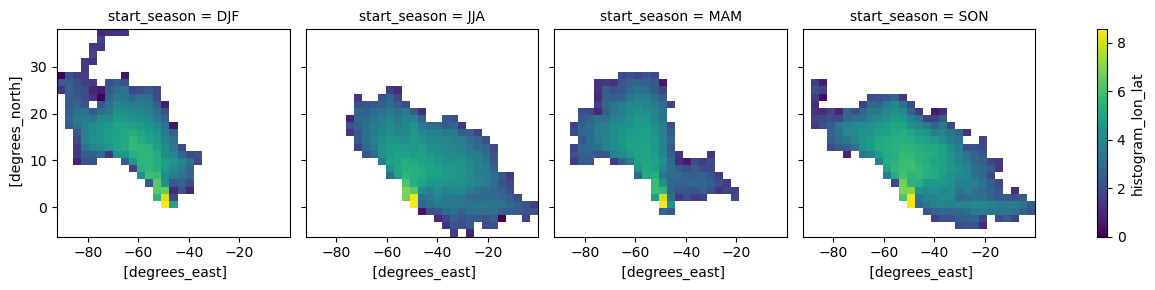

In [10]:
np.log10(hist.sum('obs').compute()).plot(
    x='lon',y='lat',
    col='start_season',col_wrap=4,
)

In [14]:
# Asegúrate de que estas sean arrays 1D
lon = ds.lon.data.flatten()
lat = ds.lat.data.flatten()
depth = ds.z.data.flatten()

# Histograma ponderado por profundidad
z_sum, xedges, yedges = np.histogram2d(
    lat, lon,  # <- orden: lat, lon = y, x
    bins=(lat_bins, lon_bins),
    weights=depth
)

# Conteo de partículas por celda
counts, _, _ = np.histogram2d(
    lat, lon,
    bins=(lat_bins, lon_bins)
)

# Calcular profundidad promedio (evitando división por 0)
z_avg = np.divide(z_sum, counts, out=np.full_like(z_sum, np.nan), where=counts != 0)


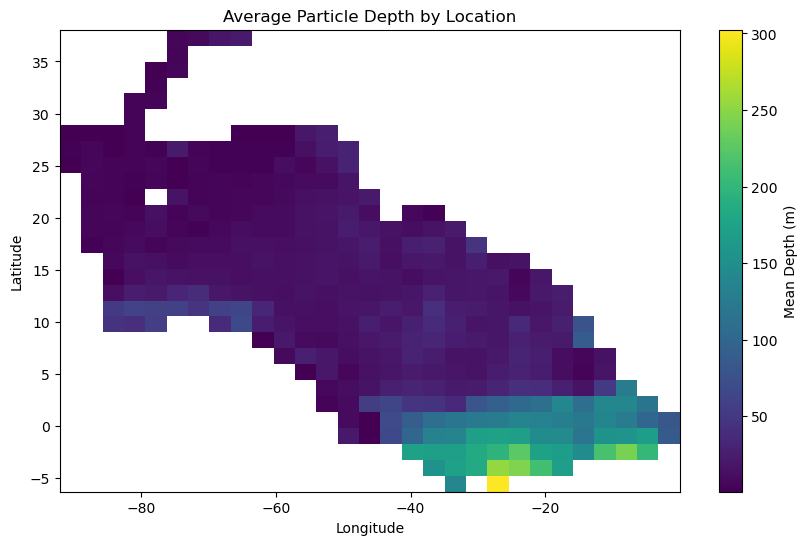

In [15]:
# Graficar con pcolormesh
plt.figure(figsize=(10, 6))
plt.pcolormesh(yedges, xedges, z_avg, cmap="viridis")  # y: lon, x: lat
plt.colorbar(label="Mean Depth (m)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Average Particle Depth by Location")
plt.show()

In [ ]:
# histogram of number of data points weighted by volume resolution
# Note that depth is a non-uniform axis

# Create a dz variable
dz = np.diff(ds.z)
dz =np.insert(dz, 0, dz[0])
# dz = xr.DataArray(dz, coords= {'z':ds.z}, dims='z')

# weight by volume of grid cell (resolution = 1/12degree, 1degree=110km)
dVol = dz * ((1/12)*110e3) * ((1/12)*110e3*np.cos(ds.lat*np.pi/180))

# Note: The weights are automatically broadcast to the right size
hTSw = xhist(ds.lon, ds.lat, bins=[lon_bins, lat_bins], weights=dVol)
np.log10(hTSw.T).plot(levels=31, vmin=11.5, vmax=16, cmap='brg')

### Monthly Variability

In [12]:
start_month = start_time.dt.month

ds['start_month'] = start_month
ds

<xarray.Dataset> Size: 56GB
Dimensions:       (trajectory: 3800000, obs: 741)
Coordinates:
  * obs           (obs) int32 3kB 0 1 2 3 4 5 6 ... 734 735 736 737 738 739 740
  * trajectory    (trajectory) int64 30MB 0 1 2 3 4 ... 99996 99997 99998 99999
Data variables:
    lat           (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    lon           (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    time          (trajectory, obs) datetime64[ns] 23GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    z             (trajectory, obs) float32 11GB dask.array<chunksize=(100000, 185), meta=np.ndarray>
    stores        (trajectory) object 30MB 'Parcels_run_1234_2022-06-01T00:00...
    start_season  (trajectory) <U3 46MB 'JJA' 'JJA' 'JJA' ... 'JJA' 'JJA' 'JJA'
    start_month   (trajectory) int64 30MB 6 6 6 6 6 6 6 6 6 ... 7 7 7 7 7 7 7 7
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4_3DCheckError
    parcels_mesh:           spherical
    parcels_version:        3.1.2

In [13]:
hist_month = ds.groupby('start_month').apply(calc_hist)
hist_month

<xarray.DataArray 'histogram_lon_lat' (start_month: 12, obs: 741, lon: 29,
                                       lat: 29)> Size: 60MB
dask.array<concatenate, shape=(12, 741, 29, 29), dtype=int64, chunksize=(1, 185, 29, 29), chunktype=numpy.ndarray>
Coordinates:
  * obs          (obs) int32 3kB 0 1 2 3 4 5 6 7 ... 734 735 736 737 738 739 740
  * lon          (lon) float32 116B -90.52 -87.34 -84.17 ... -7.94 -4.764 -1.588
  * lat          (lat) float32 116B -5.54 -4.011 -2.482 ... 34.22 35.75 37.28
  * start_month  (start_month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

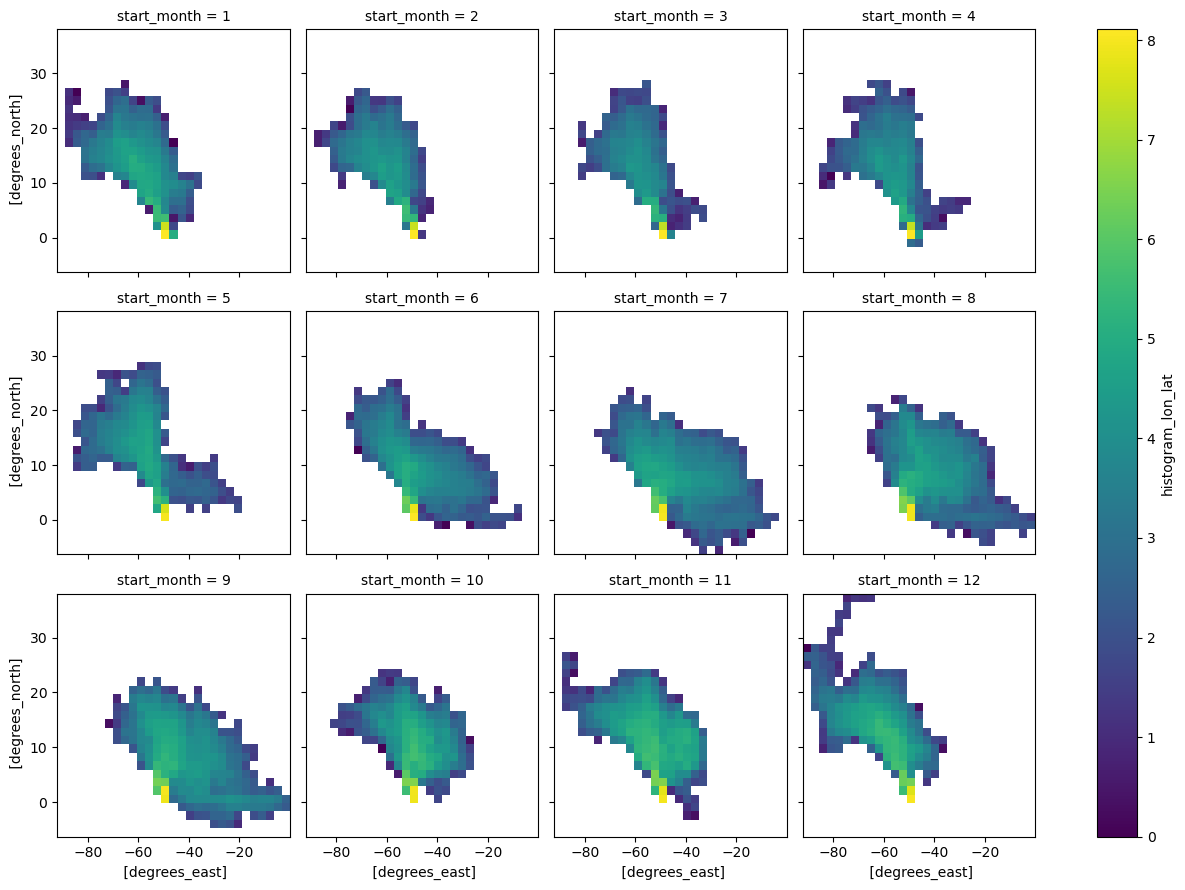

In [15]:
np.log10(hist_month.sum('obs').compute()).plot(
    x='lon',y='lat',
    col='start_month',col_wrap=4,
)